Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


Accuracy (K=3): 1.0


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]




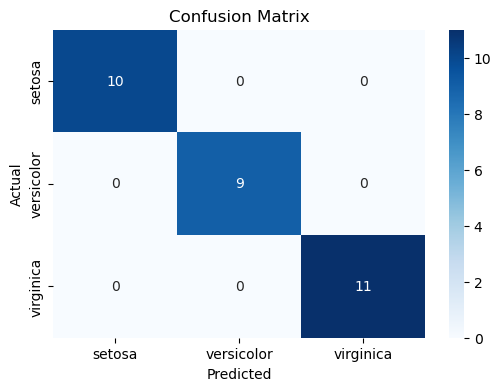

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

K vs Accuracy:

K=1, Accuracy=1.0
K=2, Accuracy=1.0
K=3, Accuracy=1.0
K=4, Accuracy=1.0
K=5, Accuracy=1.0
K=6, Accuracy=1.0
K=7, Accuracy=1.0
K=8, Accuracy=1.0
K=9, Accuracy=1.0
K=10, Accuracy=1.0


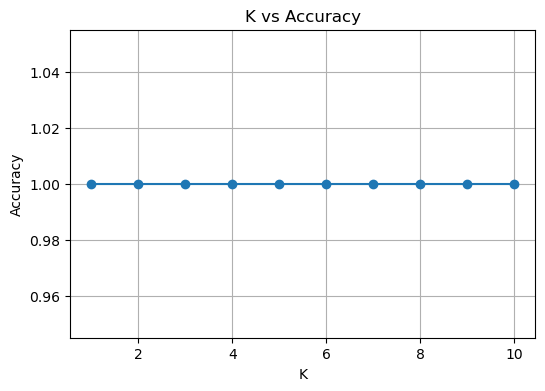


Custom Input Prediction:
Predicted class index: [0]
Flower name: setosa


In [1]:
# ==============================
# KNN COMPLETE PROJECT (IRIS)
# ==============================

# Step 1: Install libraries (run once if needed)
# !pip install numpy pandas matplotlib seaborn scikit-learn

# Step 2: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Step 3: Load Dataset
data = load_iris()

X = data.data
y = data.target

print("Feature names:", data.feature_names)
print("Target names:", data.target_names)
print("\n")

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 6: Train KNN Model
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Step 7: Predictions
y_pred = knn.predict(X_test)

# Step 8: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (K={k}):", accuracy)
print("\n")

# Step 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\n")

# Step 10: Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 11: Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Step 12: Try Different K Values
print("K vs Accuracy:\n")
k_values = list(range(1, 11))
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)
    print(f"K={k}, Accuracy={acc}")

# Step 13: Plot K vs Accuracy
plt.figure(figsize=(6,4))
plt.plot(k_values, accuracies, marker='o')
plt.title("K vs Accuracy")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

# Step 14: Predict Custom Input
sample = [[5.1, 3.5, 1.4, 0.2]]
sample_scaled = scaler.transform(sample)

prediction = knn.predict(sample_scaled)

print("\nCustom Input Prediction:")
print("Predicted class index:", prediction)
print("Flower name:", data.target_names[prediction][0])